In [2]:
!pip install pandas scikit-learn matplotlib

  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Usin


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


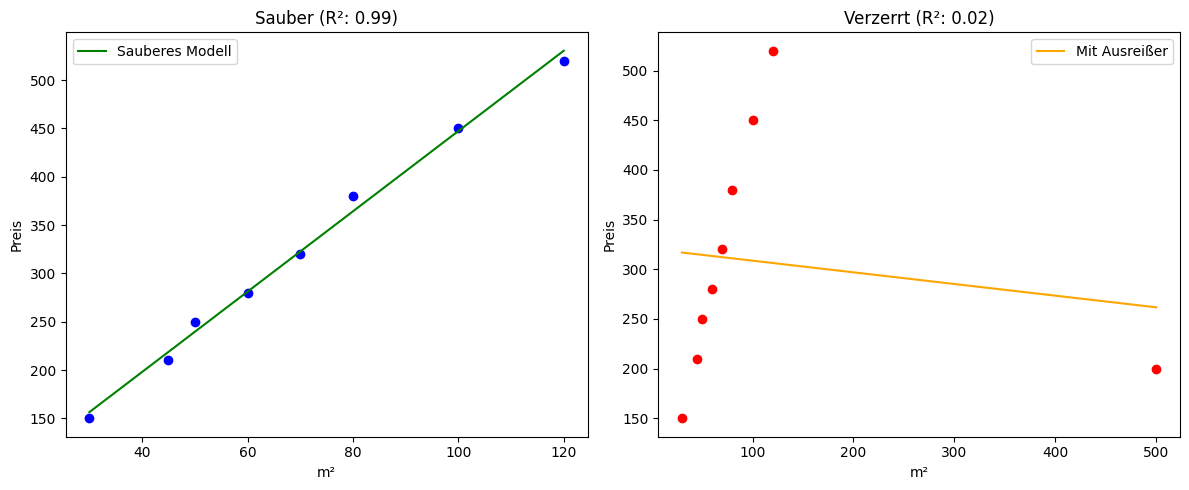

Vorhersage für 85m² (Sauber): 384.92k €
Vorhersage für 85m² (Verzerrt): 310.45k €


c:\Users\roger\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\roger\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# --- 1. DIE DATEN VORBEREITEN ---
# Saubere Daten
data_clean = {
    'meter': [30, 45, 50, 60, 70, 80, 100, 120],
    'preis': [150, 210, 250, 280, 320, 380, 450, 520]
}
df_clean = pd.DataFrame(data_clean)

# Schmutzige Daten (mit dem "Lagerhallen"-Ausreißer: 500qm für nur 200k)
data_dirty = {
    'meter': [30, 45, 50, 60, 70, 80, 100, 120, 500],
    'preis': [150, 210, 250, 280, 320, 380, 450, 520, 200]
}
df_dirty = pd.DataFrame(data_dirty)

# --- 2. MODELLE TRAINIEREN ---
# Modell A: Sauber
model_a = LinearRegression()
model_a.fit(df_clean[['meter']], df_clean['preis'])

# Modell B: Schmutzig
model_b = LinearRegression()
model_b.fit(df_dirty[['meter']], df_dirty['preis'])

# --- 3. DIE GÜTE (R²) MESSEN ---
score_a = r2_score(df_clean['preis'], model_a.predict(df_clean[['meter']]))
score_b = r2_score(df_dirty['preis'], model_b.predict(df_dirty[['meter']]))

# --- 4. VISUALISIERUNG ---
plt.figure(figsize=(12, 5))

# Plot 1: Sauberes Modell
plt.subplot(1, 2, 1) # 1 Zeile, 2 Spalten, 1. Bild
plt.scatter(df_clean['meter'], df_clean['preis'], color='blue')
plt.plot(df_clean['meter'], model_a.predict(df_clean[['meter']]), color='green', label='Sauberes Modell')
plt.title(f"Sauber (R²: {score_a:.2f})")
plt.xlabel("m²")
plt.ylabel("Preis")
plt.legend()


# Plot 2: Schmutziges Modell
plt.subplot(1, 2, 2) # 1 Zeile, 2 Spalten, 2. Bild
plt.scatter(df_dirty['meter'], df_dirty['preis'], color='red')
plt.plot(df_dirty['meter'], model_b.predict(df_dirty[['meter']]), color='orange', label='Mit Ausreißer')
plt.title(f"Verzerrt (R²: {score_b:.2f})")
plt.xlabel("m²")
plt.ylabel("Preis")
plt.legend()

plt.tight_layout()
plt.show()

# --- 5. DER "REALITÄTS-CHECK" ---
test_qm = [[85]]
print(f"Vorhersage für 85m² (Sauber): {model_a.predict(test_qm)[0]:.2f}k €")
print(f"Vorhersage für 85m² (Verzerrt): {model_b.predict(test_qm)[0]:.2f}k €")